<a href="https://colab.research.google.com/github/mariaeduardasouzabranco/AulaGitHub/blob/main/Avaliacao_II_Proposta_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação II – Aprendizado de Máquina
## Etapa 1: Proposta de projeto

**Integrantes:**
- Nome: Maria Eduarda Souza Branco  Termo: 2ºA
- Nome: Tadeu Cavalcante Pereira    Termo: 2ºA


## 1. Problema e aplicação

**Problema:** prever a **produtividade agrícola** (rendimento por hectare) de uma cultura em um país e ano, a partir de informações de clima (chuva e temperatura média) e do uso de pesticidas.

**Quem poderia usar e para quê:**
- **Governos e órgãos de planejamento agrícola:** estimar safras e antecipar riscos à segurança alimentar.
- **Cooperativas, produtores e tradings:** planejar plantio, insumos, estoque e comercialização.
- **Pesquisadores:** entender o peso de clima e insumos sobre o rendimento das culturas.

O resultado é uma estimativa de apoio à decisão, não uma previsão exata para uma propriedade específica, pois os dados são agregados por país.

## 2. Dataset e origem

- **Nome:** Crop Yield Prediction Dataset (arquivo `yield_df.csv`)
- **Link:** https://www.kaggle.com/datasets/patelris/crop-yield-prediction-dataset
- **Descrição:** tabela que combina, por país e ano, a produtividade de culturas, a chuva média anual, o uso de pesticidas e a temperatura média.
- **Origem dos dados:** segundo a descrição do Kaggle, os dados vêm da **FAO** (Organização das Nações Unidas para Alimentação e Agricultura) e do **Banco Mundial**. O pacote traz também os arquivos originais (`yield.csv`, `rainfall.csv`, `pesticides.csv`, `temp.csv`), que foram unidos para formar o `yield_df.csv`.
- **Natureza:** dados **reais**, de fonte oficial, agregados por país e ano (não são sintéticos).

## 3. Conhecimento da base

Execute as células abaixo (no Colab, envie o arquivo `yield_df.csv` pelo painel de arquivos à esquerda).


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("yield_df.csv")
df = df.drop(columns=["Unnamed: 0"])   # coluna de índice gravada junto no CSV
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [3]:
print("Linhas x colunas:", df.shape)
df.info()

Linhas x colunas: (28242, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  object 
 1   Item                           28242 non-null  object 
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.5+ MB


In [4]:
print("Valores ausentes por coluna:")
print(df.isna().sum())
print()
print("Linhas duplicadas:", df.duplicated().sum())
print("Percentual de duplicadas: %.1f%%" % (100 * df.duplicated().mean()))

Valores ausentes por coluna:
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

Linhas duplicadas: 2310
Percentual de duplicadas: 8.2%


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,28242.0,2001.544296,7.051905,1990.00,1995.0000,2001.00,2008.00,2013.00
hg/ha_yield,28242.0,77053.332094,84956.612897,50.00,19919.2500,38295.00,104676.75,501412.00
average_rain_fall_mm_per_year,28242.0,1149.055980,709.812150,51.00,593.0000,1083.00,1668.00,3240.00
pesticides_tonnes,28242.0,37076.909344,59958.784665,0.04,1702.0000,17529.44,48687.88,367778.00
avg_temp,28242.0,20.542627,6.312051,1.30,16.7025,21.51,26.00,30.65


In [6]:
print("Países:", df["Area"].nunique())
print("Culturas:", df["Item"].nunique())
print("Período:", df["Year"].min(), "a", df["Year"].max())
print()
print(df["Item"].value_counts())

Países: 101
Culturas: 10
Período: 1990 a 2013

Item
Potatoes                4276
Maize                   4121
Wheat                   3857
Rice, paddy             3388
Soybeans                3223
Sorghum                 3039
Sweet potatoes          2890
Cassava                 2045
Yams                     847
Plantains and others     556
Name: count, dtype: int64


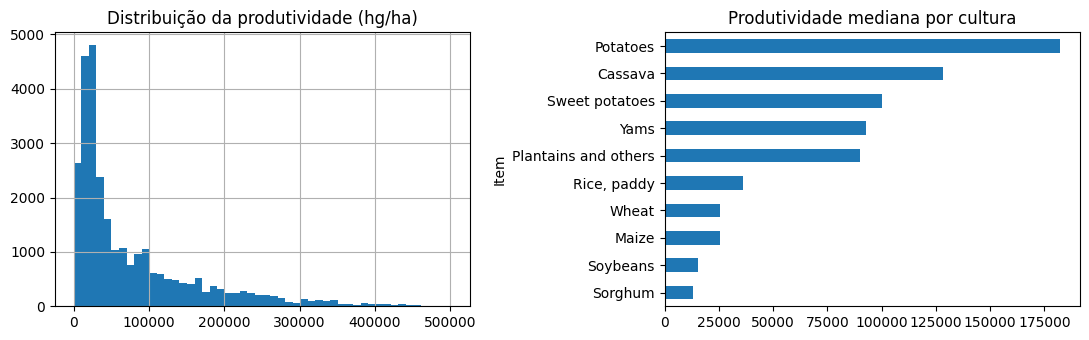

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
df["hg/ha_yield"].hist(bins=50, ax=ax[0])
ax[0].set_title("Distribuição da produtividade (hg/ha)")
df.groupby("Item")["hg/ha_yield"].median().sort_values().plot.barh(ax=ax[1])
ax[1].set_title("Produtividade mediana por cultura")
plt.tight_layout()
plt.show()

In [8]:
df.corr(numeric_only=True).round(2)

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
Year,1.00,0.09,-0.00,0.14,0.01
hg/ha_yield,0.09,1.00,0.00,0.06,-0.11
average_rain_fall_mm_per_year,-0.00,0.00,1.00,0.18,0.31
pesticides_tonnes,0.14,0.06,0.18,1.00,0.03
avg_temp,0.01,-0.11,0.31,0.03,1.00


**Significado das principais variáveis**

| Coluna | Significado |
|---|---|
| `Area` | País |
| `Item` | Cultura agrícola (batata, milho, trigo, arroz, soja, sorgo, batata-doce, mandioca, inhame e banana-da-terra/similares) |
| `Year` | Ano da observação |
| `hg/ha_yield` | Produtividade em hectogramas por hectare (**variável a prever**) |
| `average_rain_fall_mm_per_year` | Chuva média anual no país (mm) |
| `pesticides_tonnes` | Pesticidas usados no país no ano (toneladas de princípio ativo) |
| `avg_temp` | Temperatura média do país no ano (°C) |

**Valores ausentes e duplicatas (exploração inicial):** a base **não tem valores ausentes** nas colunas, mas apresenta **2.310 linhas duplicadas** (cerca de 8,2% do total), que precisarão ser tratadas na preparação dos dados. Cabe notar que os arquivos originais de chuva e de temperatura têm valores ausentes, que foram eliminados na junção que gerou o `yield_df.csv`.

## 4. Objetivo da previsão

- **Coluna a ser prevista (alvo):** `hg/ha_yield` (produtividade em hg/ha).
- **Tipo de problema:** **regressão**, pois o alvo é uma variável numérica contínua.
- **Colunas de entrada possíveis:** `Area` (país), `Item` (cultura), `Year`, `average_rain_fall_mm_per_year`, `pesticides_tonnes` e `avg_temp`. As colunas `Area` e `Item` são categóricas e precisarão de codificação.

## 5. Plano inicial

- **Algoritmo estudado:** **Random Forest Regressor** (comparando, se houver tempo, com Regressão Linear como linha de base).
- **Justificativa:** a base mistura variáveis numéricas e categóricas e a relação entre elas e o alvo não é linear (a exploração mostra correlações lineares fracas entre o alvo e as variáveis climáticas). A Random Forest captura interações e não linearidades, exige pouco ajuste de escala e oferece a importância das variáveis, o que ajuda a explicar o resultado.
- **Dificuldades previstas:**
  1. **Linhas duplicadas** (2.310) que, se mantidas, podem inflar o desempenho ao aparecerem em treino e teste.
  2. **Correlações lineares fracas** entre o alvo e as variáveis numéricas: boa parte da variação vem da cultura (`Item`) e do país (`Area`), não do clima.
  3. **Variáveis categóricas** (`Area` com 101 países, `Item` com 10 culturas) que exigem codificação adequada.
  4. **Repetição de informação:** chuva, temperatura e pesticidas são os mesmos para todas as culturas de um mesmo país e ano, o que exige cuidado na divisão treino/teste.

*A escolha do algoritmo poderá mudar no trabalho final.*